In [7]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Random_Forest_Modeling_Data.csv")

UPDATE YOUR RF MODEL to reflect tuning changes! I did not run this but you should re-run to retune the model

In [3]:
features = [
    "year",
    "latitude",
    "longitude",
    "elevation_m",
    "distance_to_coast_km",
]

target = "percent_warm_nights"
group_col = "station_id"

# Keep only rows usable for modeling
model_df = df.dropna(subset=features + [target, group_col]).copy()

print("Rows used:", len(model_df))
print("Stations used:", model_df[group_col].nunique())
print("Year range:", model_df["year"].min(), "-", model_df["year"].max())

Rows used: 10878
Stations used: 230
Year range: 1970 - 2025


In [21]:
# Make a clean modeling dataframe
# convert to floats bc pdps only work w/ floats
model_df = df.dropna(subset=features + [target, "station_id"]).copy()

# Convert all predictor columns to float
for col in features:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce").astype(float)

# Convert target to float too
model_df[target] = pd.to_numeric(model_df[target], errors="coerce").astype(float)

# Drop any rows that became NaN after conversion
model_df = model_df.dropna(subset=features + [target, "station_id"]).copy()

print(model_df[features].dtypes)

year                    float64
latitude                float64
longitude               float64
elevation_m             float64
distance_to_coast_km    float64
dtype: object


In [22]:
# reproduce your original geographic split
np.random.seed(42)

unique_stations = model_df[group_col].unique()

train_stations = np.random.choice(
    unique_stations,
    size=int(0.8 * len(unique_stations)),
    replace=False
)

train_mask = model_df[group_col].isin(train_stations)
test_mask = ~train_mask

X_train = model_df.loc[train_mask, features]
y_train = model_df.loc[train_mask, target]

X_test = model_df.loc[test_mask, features]
y_test = model_df.loc[test_mask, target]

train_groups = model_df.loc[train_mask, group_col]
test_groups = model_df.loc[test_mask, group_col]

print(f"Training stations: {train_groups.nunique()}")
print(f"Test stations: {test_groups.nunique()}")
print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Training stations: 184
Test stations: 46
Training rows: 8753
Test rows: 2125


In [8]:
# redo tuning, grouping by stations; note we only use TRAIN stations

rf_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(random_state=42, n_jobs=-1))
    ]
)

param_grid = {
    "rf__n_estimators": [300, 500, 1000],
    "rf__max_depth": [3, 5, 10, None],
    "rf__min_samples_leaf": [1, 2, 5, 10],
    "rf__max_features": ["sqrt", 0.5, 0.8, 1.0],
}

# Use grouped folds inside the training set
n_train_stations = train_groups.nunique()
n_splits = min(5, n_train_stations)

group_cv = GroupKFold(n_splits=n_splits)

grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",  # tune for MAE
    cv=group_cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid.fit(X_train, y_train, groups=train_groups)

print("Best parameters:")
print(grid.best_params_)

print("\nBest grouped-CV MAE:")
print(-grid.best_score_)

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters:
{'rf__max_depth': None, 'rf__max_features': 1.0, 'rf__min_samples_leaf': 2, 'rf__n_estimators': 1000}

Best grouped-CV MAE:
2.6121432167638443


In [9]:
# look at tuning results
cv_results = pd.DataFrame(grid.cv_results_)

cv_results["mean_test_MAE"] = -cv_results["mean_test_score"]
cv_results["mean_train_MAE"] = -cv_results["mean_train_score"]

cols_to_show = [
    "mean_test_MAE",
    "std_test_score",
    "mean_train_MAE",
    "param_rf__n_estimators",
    "param_rf__max_depth",
    "param_rf__min_samples_leaf",
    "param_rf__max_features",
]

cv_results_sorted = cv_results.sort_values("mean_test_MAE")

cv_results_sorted[cols_to_show].head(10)


,mean_test_MAE,std_test_score,mean_train_MAE,param_rf__n_estimators,param_rf__max_depth,param_rf__min_samples_leaf,param_rf__max_features
185,2.612143,0.091226,1.245128,1000,None,2,1.0
183,2.612305,0.089950,1.247206,300,None,2,1.0
184,2.612344,0.090827,1.246100,500,None,2,1.0
170,2.619669,0.073732,0.848609,1000,None,1,0.8
169,2.620714,0.078013,0.849763,500,None,1,0.8
168,2.621287,0.078074,0.851887,300,None,1,0.8
172,2.622083,0.078619,1.305786,500,None,2,0.8
173,2.622221,0.080105,1.304514,1000,None,2,0.8
171,2.622490,0.073240,1.306343,300,None,2,0.8
181,2.622705,0.083616,0.847857,500,None,1,1.0


In [23]:
# now rerun the RF regressor with tuned hyperparameters
# this is what you report as your final results
final_model = grid.best_estimator_

test_pred = final_model.predict(X_test)
train_pred = final_model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)
train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
train_r2 = r2_score(y_train, train_pred)

test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
test_r2 = r2_score(y_test, test_pred)

print("Final tuned RF performance")
print("--------------------------")
print(f"Train MAE:  {train_mae:.3f}")
print(f"Train RMSE: {train_rmse:.3f}")
print(f"Train R²:   {train_r2:.3f}")
print()
print(f"Test MAE:   {test_mae:.3f}")
print(f"Test RMSE:  {test_rmse:.3f}")
print(f"Test R²:    {test_r2:.3f}")

Final tuned RF performance
--------------------------
Train MAE:  1.218
Train RMSE: 2.004
Train R²:   0.864

Test MAE:   2.513
Test RMSE:  3.765
Test R²:    0.410


In [24]:
# compare against baseline (mean of y train)
baseline_pred = np.repeat(y_train.mean(), len(y_test))

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline performance: predict training mean")
print("------------------------------------------")
print(f"Baseline MAE:  {baseline_mae:.3f}")
print(f"Baseline RMSE: {baseline_rmse:.3f}")
print(f"Baseline R²:   {baseline_r2:.3f}")

Baseline performance: predict training mean
------------------------------------------
Baseline MAE:  3.596
Baseline RMSE: 4.913
Baseline R²:   -0.005


In [25]:
# this info should go in a table in your paper
performance_table = pd.DataFrame({
    "model": ["Training mean baseline", "Tuned random forest"],
    "test_MAE": [baseline_mae, test_mae],
    "test_RMSE": [baseline_rmse, test_rmse],
    "test_R2": [baseline_r2, test_r2],
})

performance_table

,model,test_MAE,test_RMSE,test_R2
0,Training mean baseline,3.596359,4.912712,-0.004614
1,Tuned random forest,2.513284,3.764865,0.409995


Make some final plots PDPs, permutation feature importance etc

In [13]:
pred_df = model_df.loc[test_mask, [
    "station_id",
    "station_name",
    "year",
    target
]].copy()

pred_df["predicted_percent_warm_nights"] = test_pred
pred_df["residual"] = pred_df[target] - pred_df["predicted_percent_warm_nights"]

pred_df.head()

,station_id,station_name,year,percent_warm_nights,predicted_percent_warm_nights,residual
44,USC00040212,"ANGWIN PACIFIC UNION COLLEGE, CA US",1970,4.918033,4.612366,0.305667
45,USC00040212,"ANGWIN PACIFIC UNION COLLEGE, CA US",1971,2.479339,6.585272,-4.105933
46,USC00040212,"ANGWIN PACIFIC UNION COLLEGE, CA US",1972,4.918033,6.323174,-1.405141
47,USC00040212,"ANGWIN PACIFIC UNION COLLEGE, CA US",1973,8.196721,2.679285,5.517436
48,USC00040212,"ANGWIN PACIFIC UNION COLLEGE, CA US",1974,6.837607,3.118899,3.718708


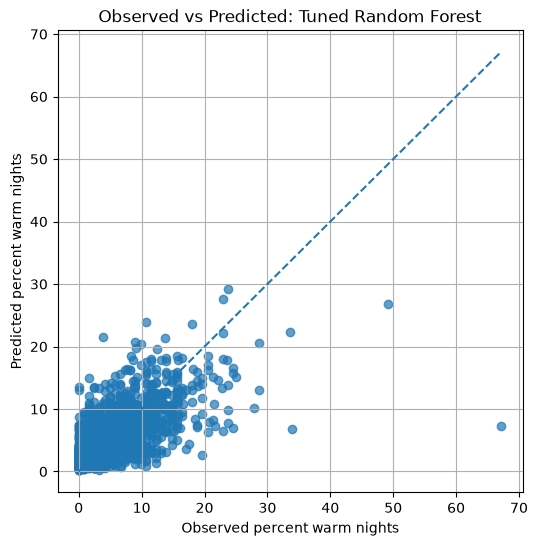

In [14]:
# observed vs predicted 
plt.figure(figsize=(6, 6))
plt.scatter(
    pred_df[target],
    pred_df["predicted_percent_warm_nights"],
    alpha=0.7
)

min_val = min(pred_df[target].min(), pred_df["predicted_percent_warm_nights"].min())
max_val = max(pred_df[target].max(), pred_df["predicted_percent_warm_nights"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Observed percent warm nights")
plt.ylabel("Predicted percent warm nights")
plt.title("Observed vs Predicted: Tuned Random Forest")
plt.grid(True)
plt.show()

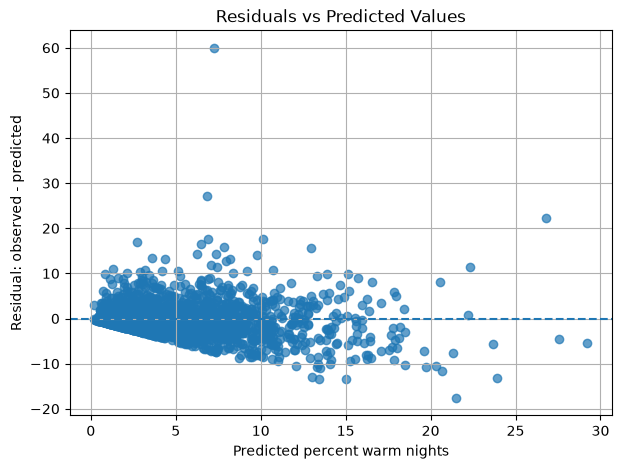

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(
    pred_df["predicted_percent_warm_nights"],
    pred_df["residual"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")
plt.xlabel("Predicted percent warm nights")
plt.ylabel("Residual: observed - predicted")
plt.title("Residuals vs Predicted Values")
plt.grid(True)
plt.show()

In [16]:
# Permutation feature importance -- show the plot below in your report
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
})

# Since scoring is negative MAE, larger positive value means permuting the feature made MAE worse.
importance_df = importance_df.sort_values("importance_mean", ascending=False)

importance_df

,feature,importance_mean,importance_std
0,year,1.913701,0.058175
4,distance_to_coast_km,0.340818,0.028343
2,longitude,0.242809,0.026162
1,latitude,0.213724,0.019122
3,elevation_m,0.139401,0.016166


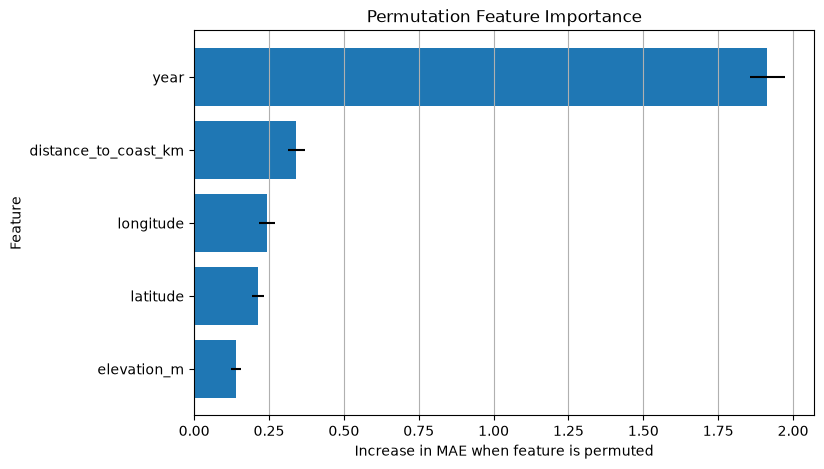

In [17]:
plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance_mean"][::-1],
    xerr=importance_df["importance_std"][::-1]
)
plt.xlabel("Increase in MAE when feature is permuted")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")
plt.grid(True, axis="x")
plt.show()

In [26]:
# partial dependence plot
pdp_features = [
    "year",
    "distance_to_coast_km",
    "elevation_m",
    "latitude",
    "longitude"
]

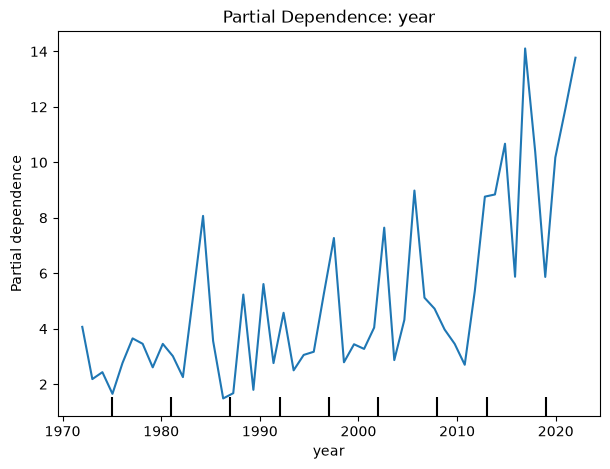

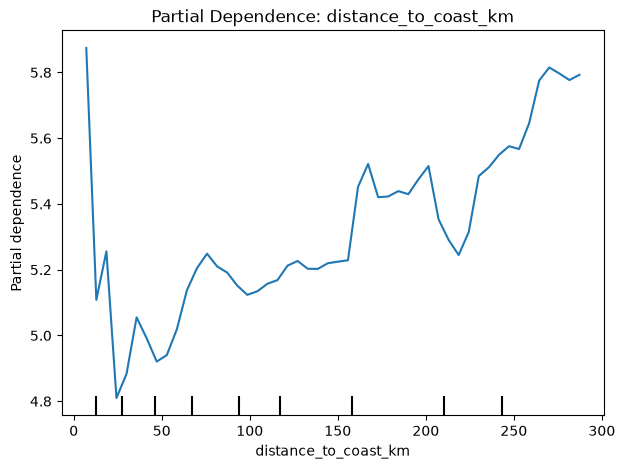

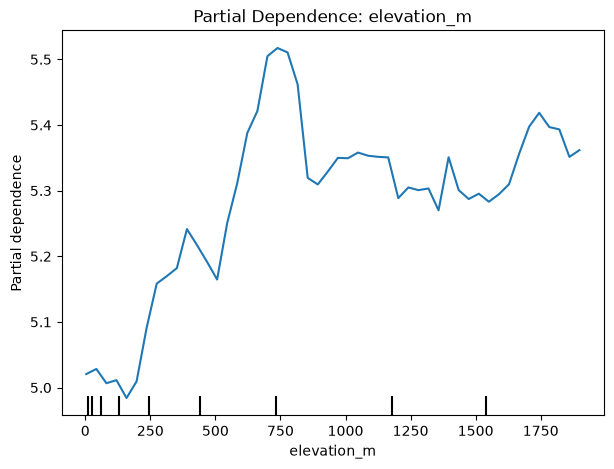

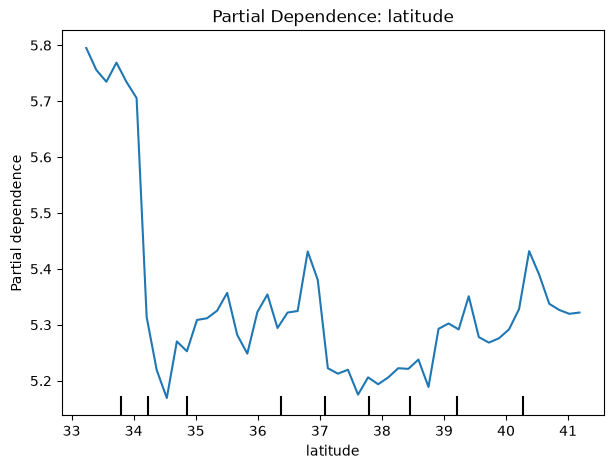

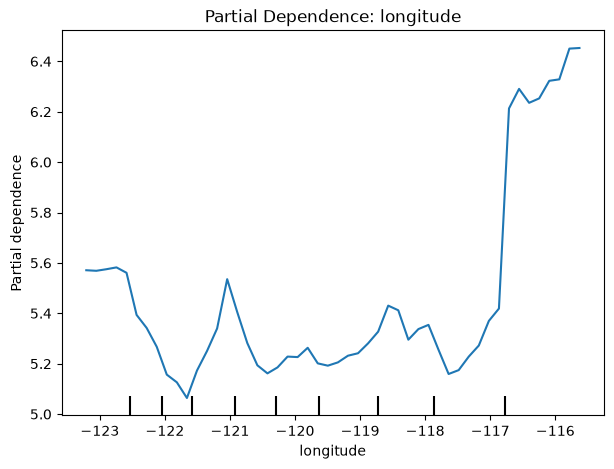

In [27]:
for feat in pdp_features:
    fig, ax = plt.subplots(figsize=(7, 5))

    PartialDependenceDisplay.from_estimator(
        final_model,
        X_train,          # use training data distribution as background
        features=[feat],
        ax=ax,
        grid_resolution=50
    )

    ax.set_title(f"Partial Dependence: {feat}")
    ax.grid(True)

    plt.show()